# QRC Swaption Surface — Visualizations

Standalone notebook. Requires `val_true.csv` and `val_pred.csv` saved by `research_paper V2.ipynb`.

**Figures produced:**
1. Actual vs Predicted surface heatmap (single day)
2. Mean absolute error heatmap over all validation days
3. Per-maturity QLIKE profile
4. Model comparison bar chart (all QLIKE scores)
5. Predicted vs Actual scatter (all cells, all days)
6. Time-series prediction for a representative vol cell

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import BoundaryNorm
import warnings
warnings.filterwarnings('ignore')

# ── Style ────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})
EPS = 1e-6

In [15]:
import os
from google.colab import drive

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")
    print("Drive mounted ✓")
else:
    print("Drive already mounted ✓")

Drive already mounted ✓


In [16]:
# ─────────────────────────────────────────────
# LOAD PREDICTIONS
# ─────────────────────────────────────────────

DATA_DIR = "/content/drive/MyDrive/qrc_results"   # same as SAVE_DIR in V2

df_true = pd.read_csv(f"{DATA_DIR}/val_true.csv")
df_pred = pd.read_csv(f"{DATA_DIR}/val_pred.csv")

feature_cols  = list(df_true.columns)
val_true      = df_true.values.astype(np.float32)   # (N_val, 224)
val_pred      = df_pred.values.astype(np.float32)   # (N_val, 224)
N_val         = len(val_true)

# Parse grid dimensions from column names
# Format: 'Tenor : X; Maturity : Y'
tenors     = sorted(set(int(c.split('Tenor : ')[1].split(';')[0])   for c in feature_cols))
maturities = sorted(set(float(c.split('Maturity : ')[1])            for c in feature_cols))
N_T, N_M   = len(tenors), len(maturities)

mat_labels = [f'{m:.2f}' if m < 1 else f'{m:.0f}' for m in maturities]

def to_grid(flat_array):
    """Reshape (224,) → (N_T=14, N_M=16) ordered by [tenor, maturity]."""
    grid = np.zeros((N_T, N_M), dtype=np.float32)
    for ci, col in enumerate(feature_cols):
        t = int(col.split('Tenor : ')[1].split(';')[0])
        m = float(col.split('Maturity : ')[1])
        grid[tenors.index(t), maturities.index(m)] = flat_array[ci]
    return grid

def qlike(true, pred):
    p = np.clip(pred, EPS, None)
    t = np.clip(true, EPS, None)
    r = t / p
    return float(np.mean(r**2 - 2*np.log(r) - 1))

print(f"Loaded: {N_val} validation days, {N_T} tenors × {N_M} maturities = {N_T*N_M} cells")
print(f"Tenors    : {tenors}")
print(f"Maturities: {mat_labels}")

Loaded: 74 validation days, 14 tenors × 16 maturities = 224 cells
Tenors    : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30]
Maturities: ['0.08', '0.25', '0.50', '0.75', '1', '2', '2', '3', '4', '5', '7', '10', '15', '20', '25', '30']


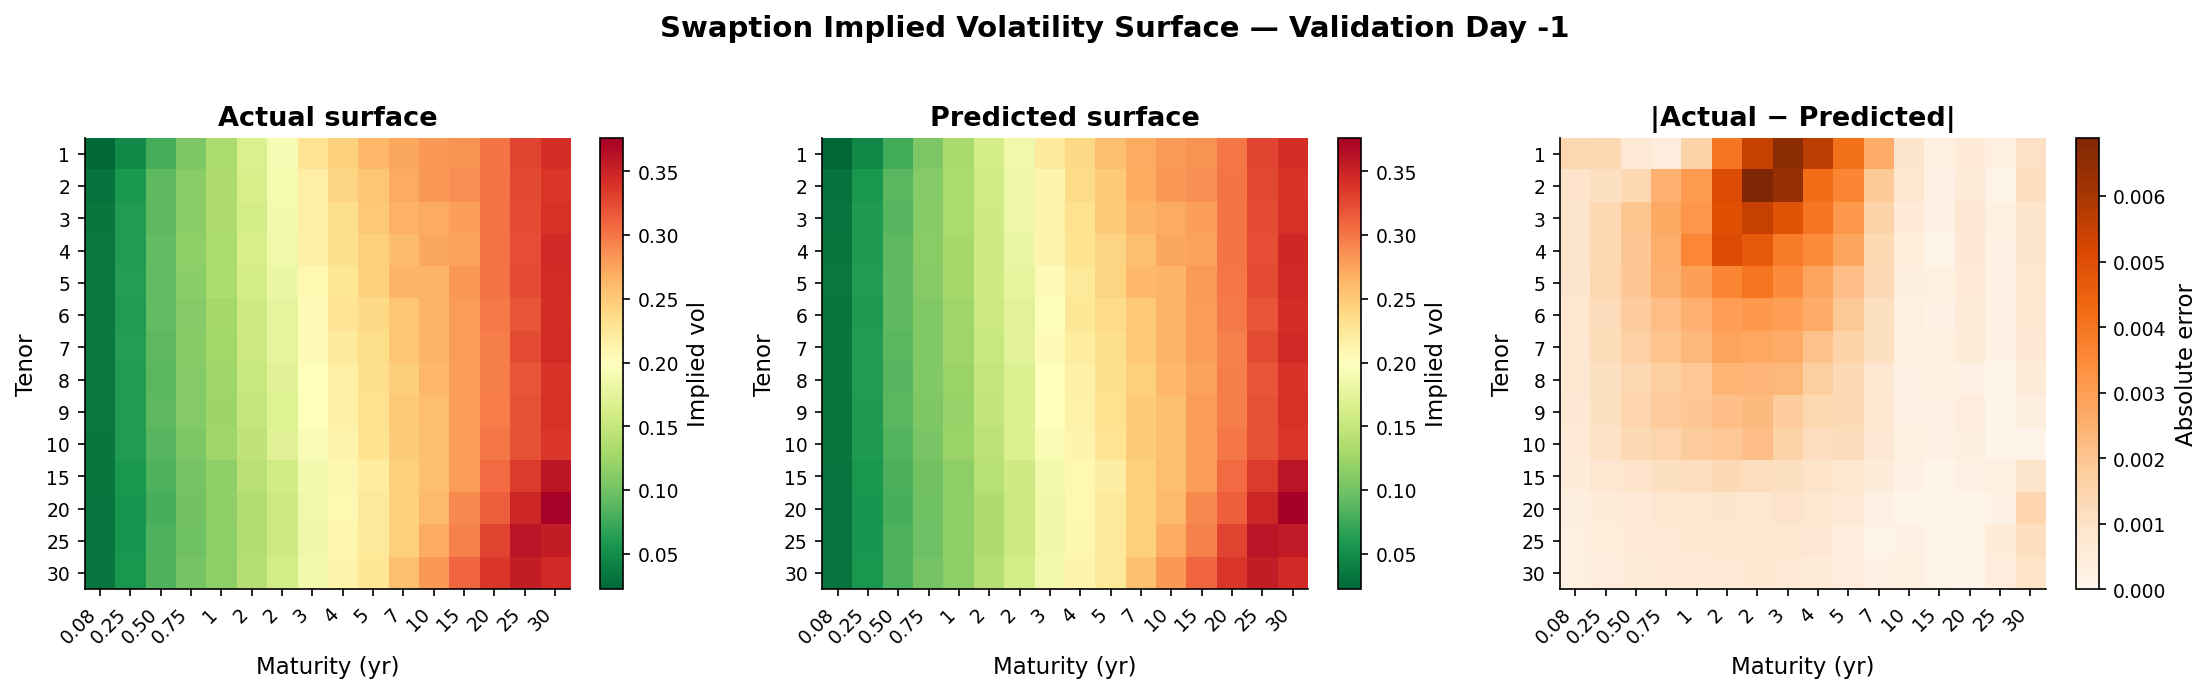

Day -1  QLIKE: 0.000406


In [17]:
# ═══════════════════════════════════════════════════════════════════════
# FIGURE 1 — Actual vs Predicted Surface (last validation day)
# ═══════════════════════════════════════════════════════════════════════

DAY = -1   # last validation day; change to any index 0..N_val-1

true_grid  = to_grid(val_true[DAY])
pred_grid  = to_grid(val_pred[DAY])
vmin       = min(true_grid.min(), pred_grid.min())
vmax       = max(true_grid.max(), pred_grid.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5),
                          gridspec_kw={'width_ratios': [1, 1, 1]})

kw = dict(cmap='RdYlGn_r', vmin=vmin, vmax=vmax, aspect='auto')

for ax, grid, title in zip(axes[:2],
                            [true_grid, pred_grid],
                            ['Actual surface', 'Predicted surface']):
    im = ax.imshow(grid, **kw)
    ax.set_xticks(range(N_M))
    ax.set_xticklabels(mat_labels, rotation=45, ha='right')
    ax.set_yticks(range(N_T))
    ax.set_yticklabels([str(t) for t in tenors])
    ax.set_xlabel('Maturity (yr)')
    ax.set_ylabel('Tenor')
    ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Implied vol')

# Error panel
err_grid = np.abs(true_grid - pred_grid)
im3 = axes[2].imshow(err_grid, cmap='Oranges', aspect='auto',
                      vmin=0, vmax=err_grid.max())
axes[2].set_xticks(range(N_M))
axes[2].set_xticklabels(mat_labels, rotation=45, ha='right')
axes[2].set_yticks(range(N_T))
axes[2].set_yticklabels([str(t) for t in tenors])
axes[2].set_xlabel('Maturity (yr)')
axes[2].set_ylabel('Tenor')
axes[2].set_title('|Actual − Predicted|', fontweight='bold')
plt.colorbar(im3, ax=axes[2], label='Absolute error')

fig.suptitle(f'Swaption Implied Volatility Surface — Validation Day {DAY}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/fig1_surface_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Day {DAY}  QLIKE: {qlike(val_true[DAY], val_pred[DAY]):.6f}")

In [19]:
DATA_DIR

'/content/drive/MyDrive/qrc_results'

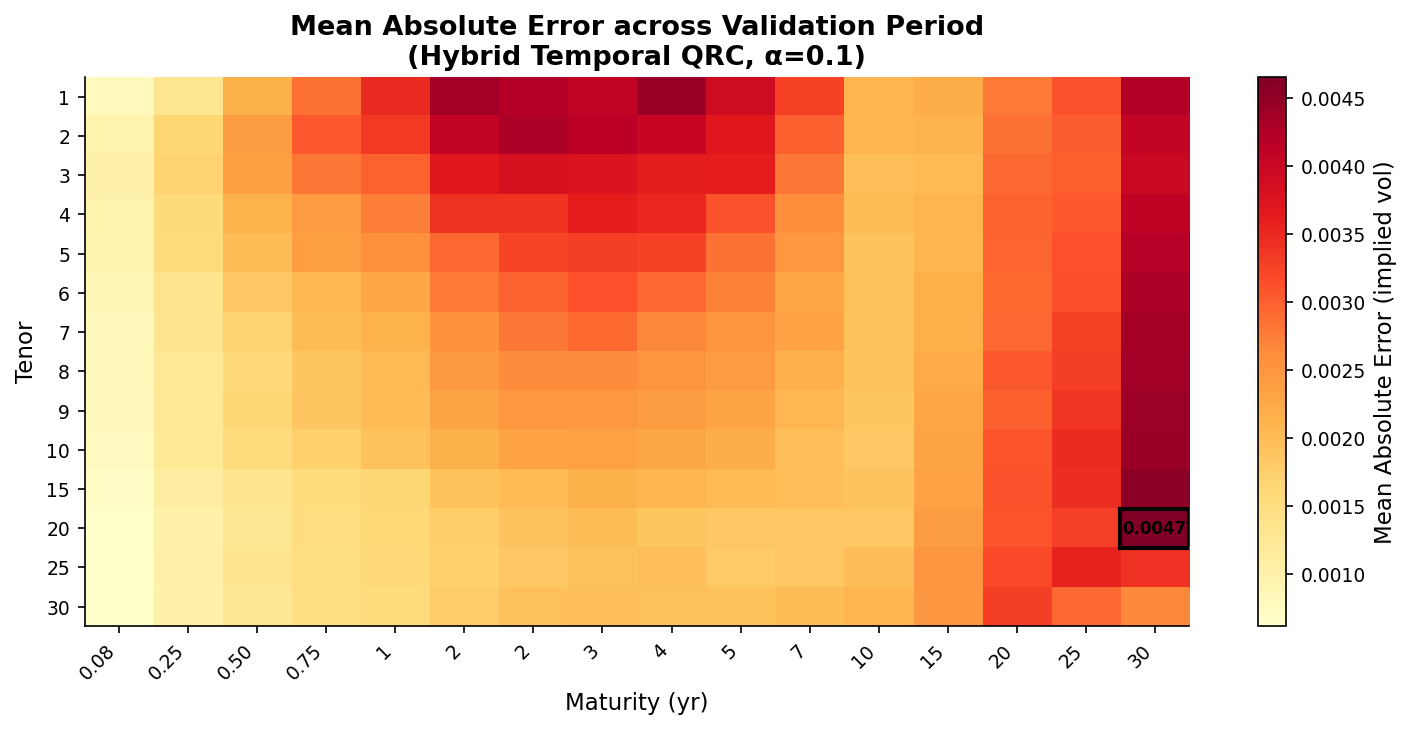

In [18]:
# ═══════════════════════════════════════════════════════════════════════
# FIGURE 2 — Mean Absolute Error Heatmap (averaged over all val days)
# ═══════════════════════════════════════════════════════════════════════

mae_per_cell = np.mean(np.abs(val_true - val_pred), axis=0)   # (224,)
mae_grid     = to_grid(mae_per_cell)                           # (14, 16)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(mae_grid, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='Mean Absolute Error (implied vol)')

ax.set_xticks(range(N_M))
ax.set_xticklabels(mat_labels, rotation=45, ha='right')
ax.set_yticks(range(N_T))
ax.set_yticklabels([str(t) for t in tenors])
ax.set_xlabel('Maturity (yr)')
ax.set_ylabel('Tenor')
ax.set_title('Mean Absolute Error across Validation Period\n'
             '(Hybrid Temporal QRC, α=0.1)',
             fontweight='bold')

# Annotate worst cell
worst = np.unravel_index(mae_grid.argmax(), mae_grid.shape)
ax.add_patch(plt.Rectangle((worst[1]-0.5, worst[0]-0.5), 1, 1,
                             fill=False, edgecolor='black', lw=2))
ax.text(worst[1], worst[0],
        f"{mae_grid[worst]:.4f}",
        ha='center', va='center', fontsize=8, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/fig2_mae_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

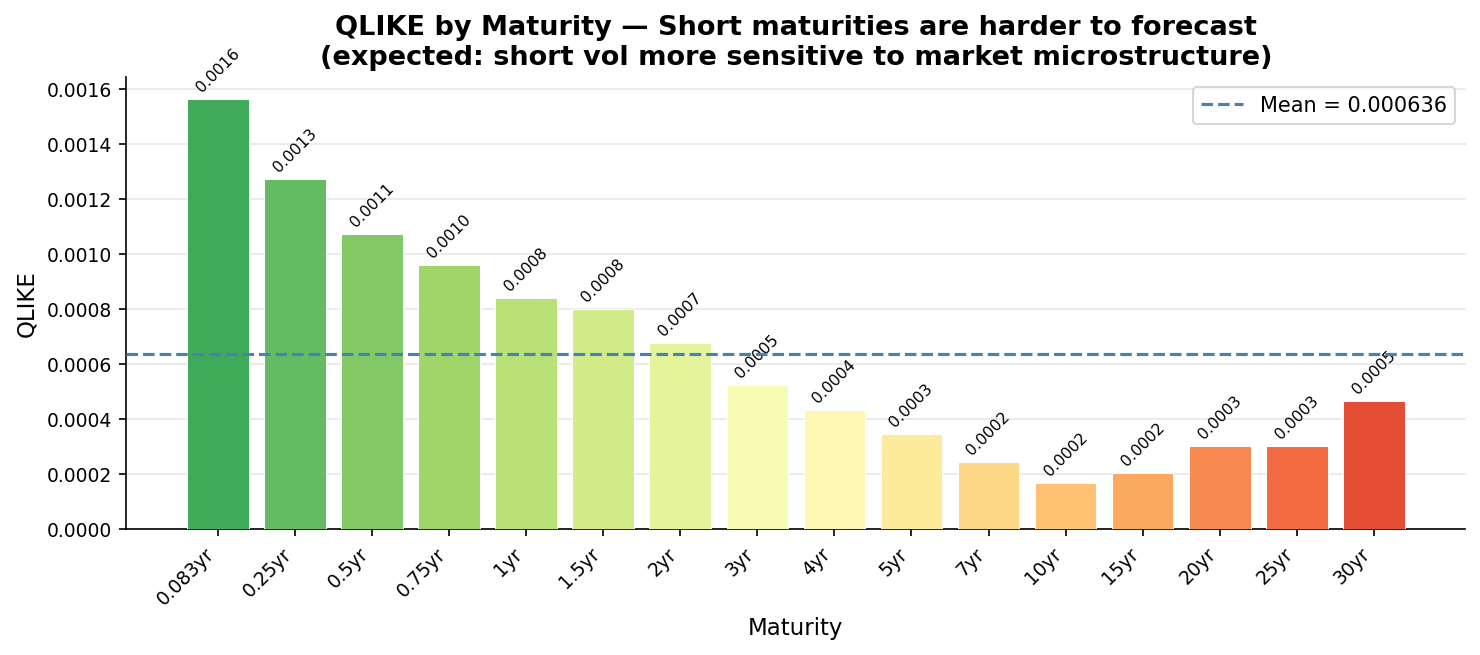

In [5]:
# ═══════════════════════════════════════════════════════════════════════
# FIGURE 3 — Per-Maturity QLIKE Profile
# ═══════════════════════════════════════════════════════════════════════

qlike_per_mat = []
for mat in maturities:
    idx = [i for i, c in enumerate(feature_cols)
           if float(c.split('Maturity : ')[1]) == mat]
    qlike_per_mat.append(qlike(val_true[:, idx], val_pred[:, idx]))

fig, ax = plt.subplots(figsize=(10, 4.5))

colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, N_M))
bars   = ax.bar(range(N_M), qlike_per_mat, color=colors, edgecolor='white',
                linewidth=0.5, zorder=3)

# Annotate each bar
for bar, val in zip(bars, qlike_per_mat):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(qlike_per_mat)*0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=7.5, rotation=45)

ax.axhline(np.mean(qlike_per_mat), color='steelblue', linestyle='--',
           linewidth=1.5, label=f'Mean = {np.mean(qlike_per_mat):.6f}', zorder=4)

ax.set_xticks(range(N_M))
ax.set_xticklabels([f'{m:.2g}yr' for m in maturities], rotation=45, ha='right')
ax.set_xlabel('Maturity')
ax.set_ylabel('QLIKE')
ax.set_title('QLIKE by Maturity — Short maturities are harder to forecast\n'
             '(expected: short vol more sensitive to market microstructure)',
             fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/fig3_qlike_per_maturity.png', bbox_inches='tight', dpi=150)
plt.show()

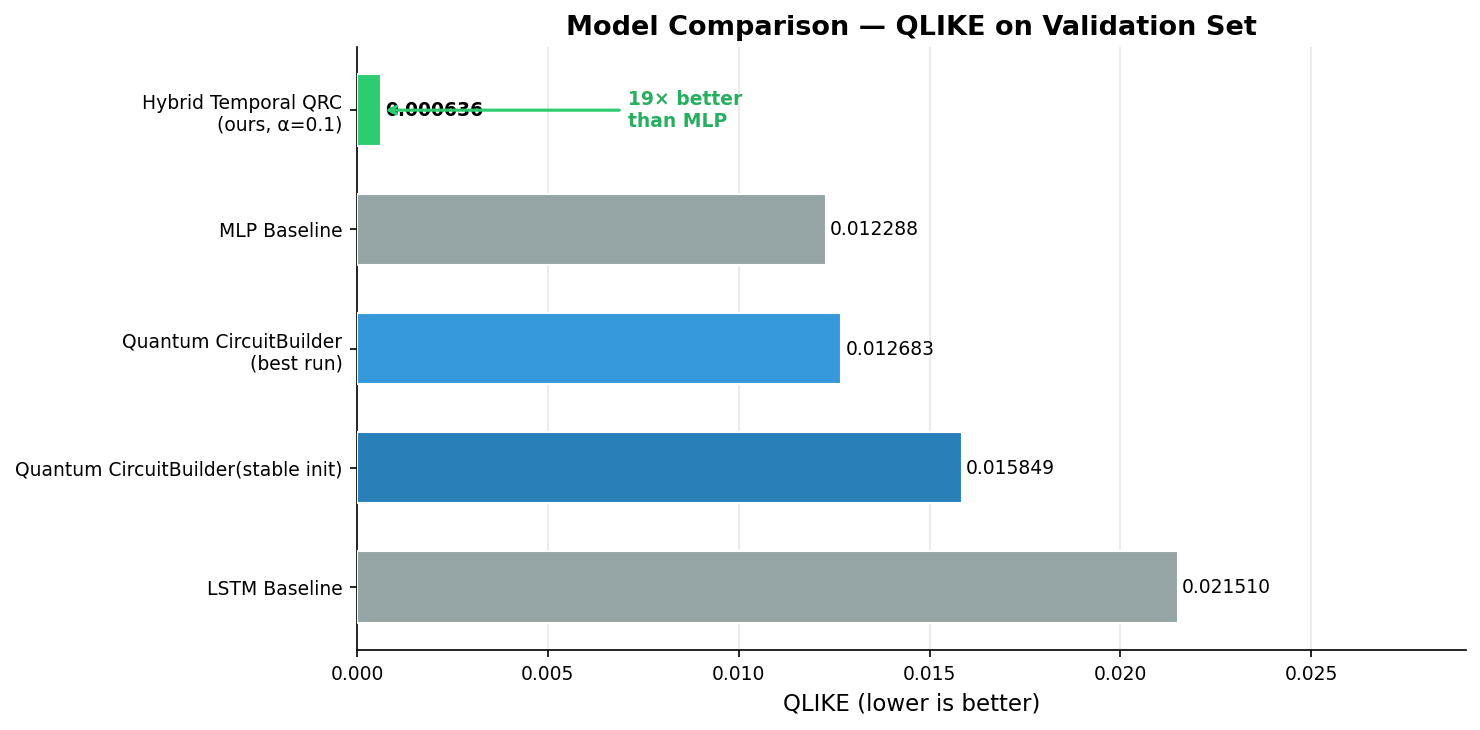

In [7]:
# ═══════════════════════════════════════════════════════════════════════
# FIGURE 4 — Model Comparison Bar Chart
# ═══════════════════════════════════════════════════════════════════════

models = [
    ('Hybrid Temporal QRC\n(ours, α=0.1)',  0.000636, '#2ecc71'),
    ('MLP Baseline',                         0.012288, '#95a5a6'),
    ('Quantum CircuitBuilder\n(best run)',   0.012683, '#3498db'),
    ('Quantum CircuitBuilder(stable init)',            0.015849, '#2980b9'),
    ('LSTM Baseline',                        0.021510, '#95a5a6'),
]

labels  = [m[0] for m in models]
values  = [m[1] for m in models]
colors  = [m[2] for m in models]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(range(len(models)), values, color=colors,
               edgecolor='white', height=0.6, zorder=3)

for bar, val, color in zip(bars, values, colors):
    ax.text(val + max(values)*0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.6f}', va='center', fontsize=9,
            fontweight='bold' if val == min(values) else 'normal')

# Improvement annotation
best  = min(values)
mlp   = 0.012288
ax.annotate(
    f'{mlp/best:.0f}× better\nthan MLP',
    xy=(best, 0), xytext=(best + max(values)*0.3, 0),
    arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=1.5),
    fontsize=9, color='#27ae60', fontweight='bold',
    va='center'
)

ax.set_yticks(range(len(models)))
ax.set_yticklabels(labels)
ax.set_xlabel('QLIKE (lower is better)')
ax.set_title('Model Comparison — QLIKE on Validation Set',
             fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, zorder=0)
ax.set_xlim(0, max(values) * 1.35)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/fig4_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

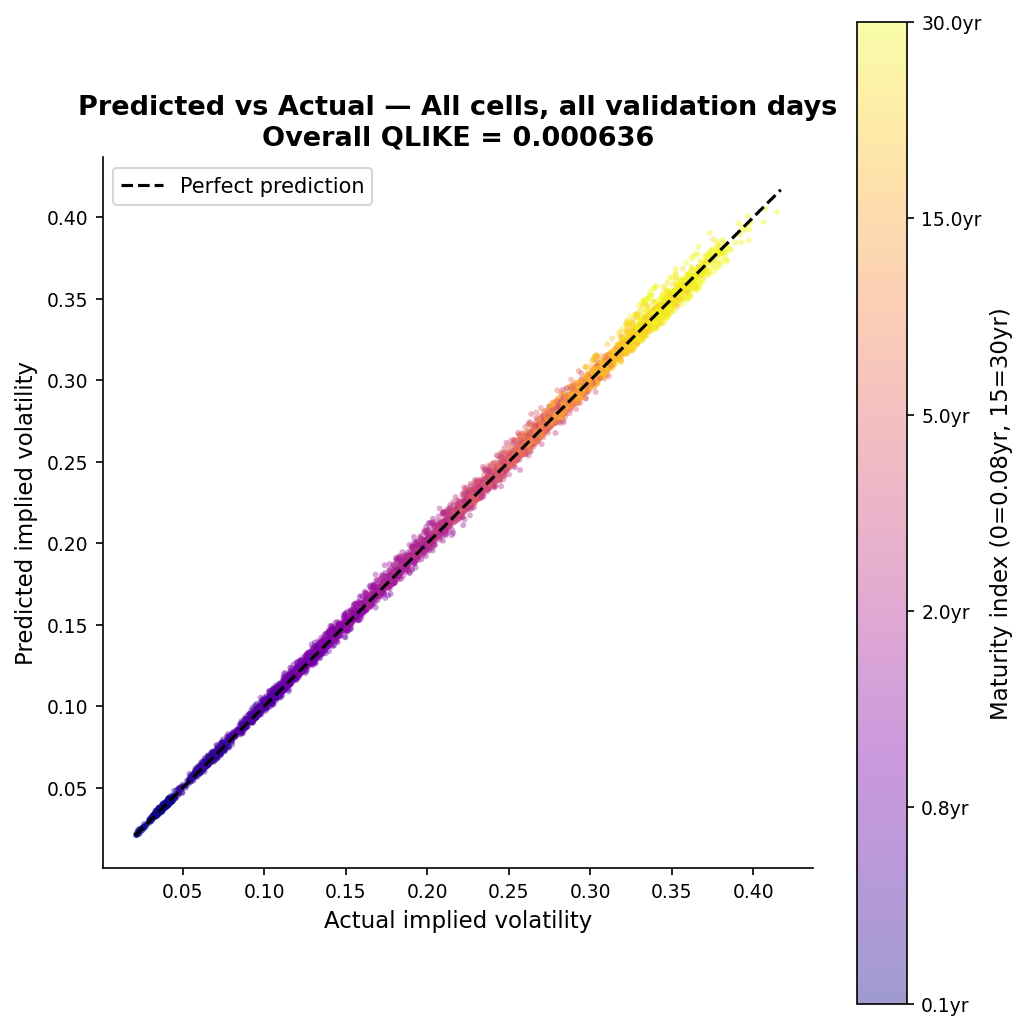

In [8]:
# ═══════════════════════════════════════════════════════════════════════
# FIGURE 5 — Predicted vs Actual Scatter (all cells, all val days)
# ═══════════════════════════════════════════════════════════════════════

# Assign a maturity index to each of the 224 columns for coloring
mat_idx_per_col = np.array([
    maturities.index(float(c.split('Maturity : ')[1]))
    for c in feature_cols
])

# Flatten: (N_val, 224) → (N_val*224,)
true_flat = val_true.flatten()
pred_flat = val_pred.flatten()
mat_flat  = np.tile(mat_idx_per_col, N_val)   # maturity index for each point

# Subsample for readability (all ~16k points is fine but looks dense)
rng  = np.random.default_rng(42)
idx  = rng.choice(len(true_flat), size=min(8000, len(true_flat)), replace=False)

fig, ax = plt.subplots(figsize=(7, 7))

sc = ax.scatter(true_flat[idx], pred_flat[idx],
                c=mat_flat[idx], cmap='plasma',
                alpha=0.4, s=8, linewidths=0)

# Perfect prediction line
lims = [min(true_flat.min(), pred_flat.min()),
        max(true_flat.max(), pred_flat.max())]
ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect prediction', zorder=5)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Maturity index (0=0.08yr, 15=30yr)')
cbar.set_ticks(range(0, N_M, 3))
cbar.set_ticklabels([f'{maturities[i]:.1f}yr' for i in range(0, N_M, 3)])

ax.set_xlabel('Actual implied volatility')
ax.set_ylabel('Predicted implied volatility')
ax.set_title('Predicted vs Actual — All cells, all validation days\n'
             f'Overall QLIKE = {qlike(val_true, val_pred):.6f}',
             fontweight='bold')
ax.legend()
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/fig5_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

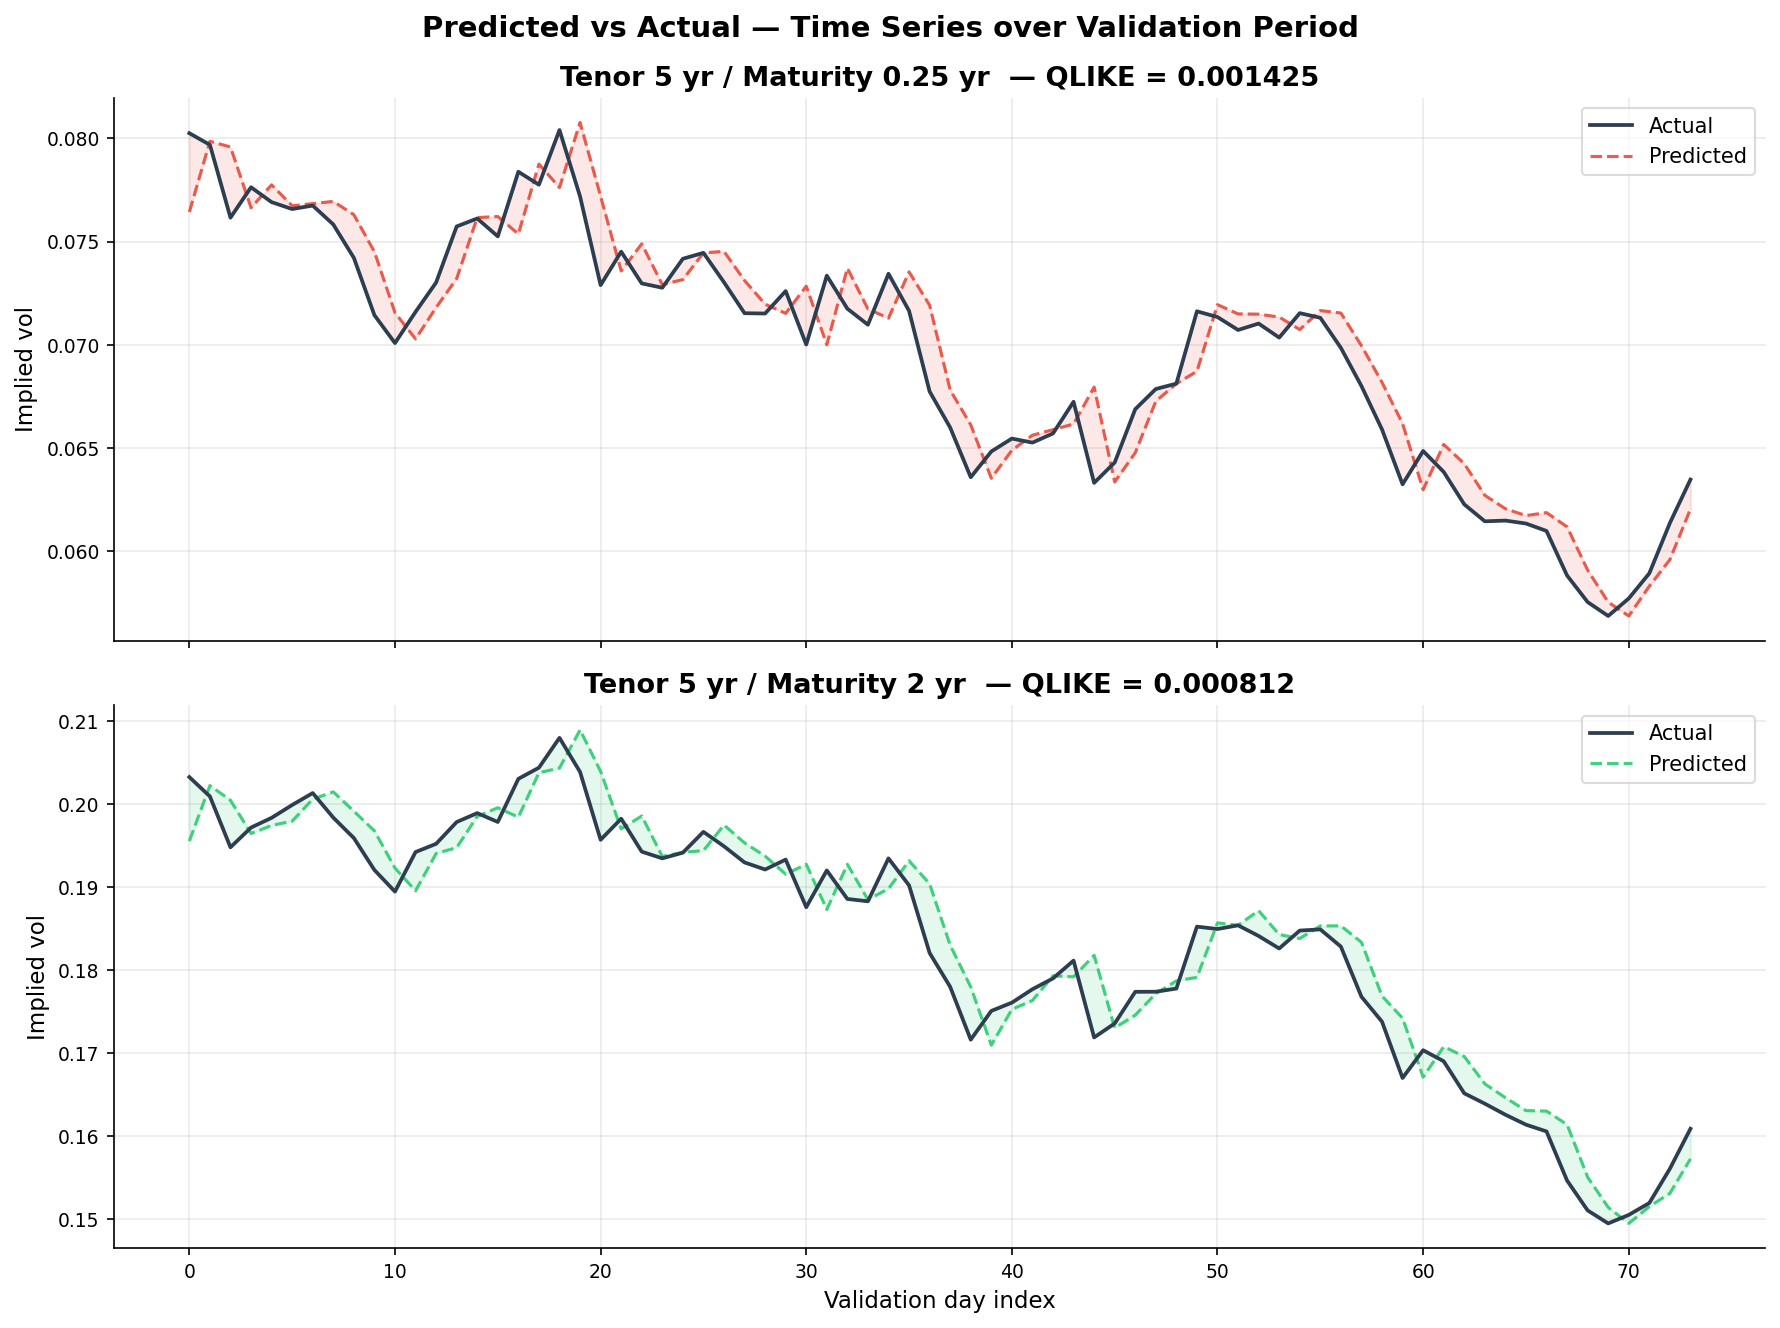

In [11]:
# ═══════════════════════════════════════════════════════════════════════
# FIGURE 6 — Time-Series: Predicted vs Actual for 3 representative cells
# ═══════════════════════════════════════════════════════════════════════
# Show how predictions track reality over the 74 validation days
# for short, medium, and long maturities.

TENOR_TARGET = 5   # Tenor 5 (mid-range)
MAT_TARGETS  = [maturities[1], maturities[5]]   # 0.25yr, 1.5yr, 15yr
days         = np.arange(N_val)

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

palette = ['#e74c3c', '#2ecc71', '#3498db']

for ax, mat, color in zip(axes, MAT_TARGETS, palette):
    # Find column index for this (tenor, maturity) cell
    col_name = f'Tenor : {TENOR_TARGET}; Maturity : {mat}'
    ci = feature_cols.index(col_name)

    true_ts = val_true[:, ci]
    pred_ts = val_pred[:, ci]
    cell_qlike = qlike(true_ts.reshape(-1,1), pred_ts.reshape(-1,1))

    ax.plot(days, true_ts, color='#2c3e50', linewidth=1.8,
            label='Actual', zorder=4)
    ax.plot(days, pred_ts, color=color, linewidth=1.5,
            linestyle='--', label='Predicted', zorder=3, alpha=0.9)
    ax.fill_between(days, true_ts, pred_ts,
                    alpha=0.12, color=color, zorder=2)

    mat_label = f'{mat:.2f}' if mat < 1 else f'{mat:.0f}'
    ax.set_title(f'Tenor {TENOR_TARGET} yr / Maturity {mat_label} yr  '
                 f'— QLIKE = {cell_qlike:.6f}',
                 fontweight='bold')
    ax.set_ylabel('Implied vol')
    ax.legend(loc='upper right', framealpha=0.7)
    ax.grid(alpha=0.25)

axes[-1].set_xlabel('Validation day index')
fig.suptitle('Predicted vs Actual — Time Series over Validation Period',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/fig6_timeseries.png', bbox_inches='tight', dpi=150)
plt.show()